0.9604773918266578
0.5399802078386209
3.327762441749732
0.46306535637628343
1.1811862179008443
1.7335812521784346
0.36930564513018904
2.03751254729279
1.0646544823700275
0.8162268645469002


Max residual error:  3.327762441749732   At: ( 2  ,  3.682841362658211 )
Min residual error:  0.36930564513018904   At: ( 6  ,  6.252400971391289 )


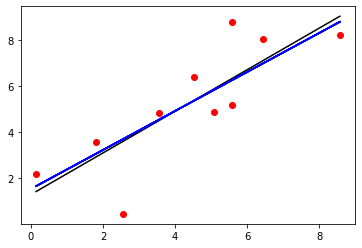

In [3]:
#randomized values and perturbations numpy built in
import matplotlib.pyplot as plt
import numpy as np
import random
list_length = 10
max_point = [0,0,0] #x,y,error
min_point = [0,0,11] #x,y,error

X = np.array([random.uniform(0,10) for _ in range(list_length)])
Y = np.array([random.uniform(0,10) for _ in range(list_length)])
X.sort()
# Data points
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

plt.scatter(X,Y, color = "red") #the data points
plt.plot(X, m*X + c, color ="black") #the basic line


for i in range (0,len(Y)):
    y_val = Y[i]
    Y[i] = y_val + random.uniform(-1,1) #add error
    
    
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
#finding the residuals between the data and the new function
for i in range (0,len(Y)):
    residual_error = abs((m*X[i] + c) - Y[i])    
    print(residual_error)
    if residual_error > max_point[2]:
        max_point[0] = i
        max_point[1] = m*X[i] + c
        max_point[2] = residual_error

    if residual_error < min_point[2]:
        min_point[0] = i
        min_point[1] = m*X[i] + c
        min_point[2] = residual_error

    plt.plot(X, m*X + c, color = "blue")


#find max min residuals
print("\n")
print("Max residual error: ", max_point[2], "  At: (", max_point[0], " , ", max_point[1], ")")
print("Min residual error: ", min_point[2], "  At: (", min_point[0], " , ", min_point[1], ")")

In [5]:
#Recreate the least squares solution, and get similar results for the same equation
#Also print out the residuals, identify the points with the largest and smallest residual errors.
#Compare the results of your custom Least Square Method to the the Numpy version.
#Plot the points, and the predicted line.
